# mplp Quickstart

**mplp** (MatPlotLib Prettifier) makes matplotlib plots publication-ready with a single function call.

Instead of hunting through matplotlib's documentation, you just look at `mplp`'s signature — every common tweak is an argument.

## Setup

Before running this notebook, install the package from the repo root:

```bash
uv sync
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Shared data for many examples
x = np.linspace(0, 10, 200)
y = np.sin(x) * np.exp(-x / 5)

In [2]:
%load_ext autoreload
%autoreload 2
import mplp

---
## 1. One call to `mplp()` — zero arguments

The simplest use case: make any plot pretty with no arguments at all.

(<Figure size 1000x350 with 2 Axes>,
 <Axes: title={'center': 'Default mplp'}, xlabel='Time (s)', ylabel='Amplitude'>)

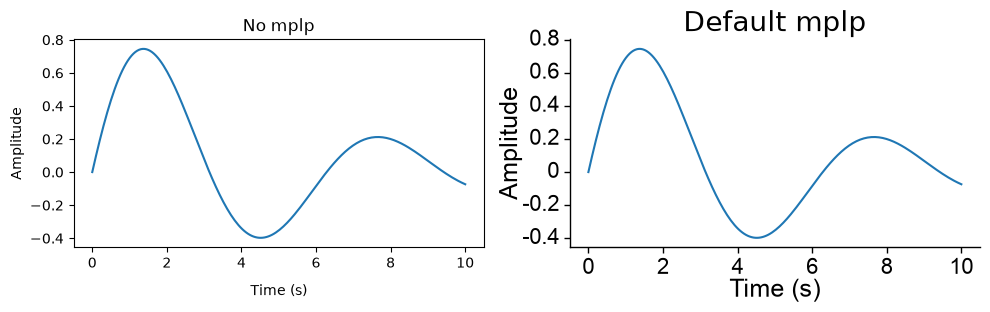

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(x, y)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

axes[0].set_title('Default matplotlib')

# mplp grabs the current figure with matplotlib.gcf()
# and current axes with matplotlib.gca() (here, axes[1])
# if no fig or ax is provided.
mplp.mplp(title='Default mplp', tight_layout=True)

---
## 2. Customising axes: limits, ticks, labels

(<Figure size 1000x350 with 2 Axes>,
 <Axes: title={'center': 'Set limits and ticks!'}, xlabel='Time (s)', ylabel='Amplitude (a.u.)'>)

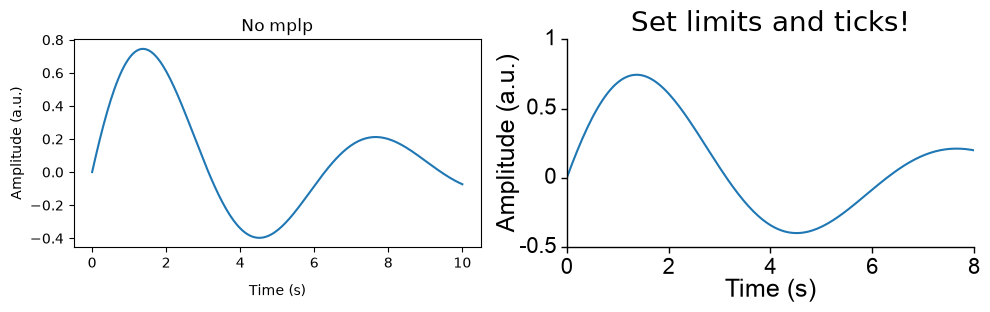

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(x, y)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (a.u.)')

axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    xlim=(0, 8),
    ylim=(-0.5, 1),
    xticks=[0, 2, 4, 6, 8],
    yticks=[-0.5, 0, 0.5, 1],
    xlabel='Time (s)',
    ylabel='Amplitude (a.u.)',
    title='Set limits and ticks!',
    tight_layout=True,
)

---
## 3. Smart tick generation with `get_bestticks`

In [5]:
# get_bestticks picks nice round values automatically
print('Ticks for 0-100:  ', mplp.get_bestticks(0, 100))
print('Ticks for 0-50:   ', mplp.get_bestticks(0, 50))
print('Ticks for 0-10:   ', mplp.get_bestticks(0, 10))
print('Ticks for 0-0.5:  ', mplp.get_bestticks(0, 0.5))
print('Light ticks 0-100:', mplp.get_bestticks(0, 100, light=True))

Ticks for 0-100:   [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]
Ticks for 0-50:    [ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50.]
Ticks for 0-10:    [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Ticks for 0-0.5:   [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
Light ticks 0-100: [  0.  20.  40.  60.  80. 100.]


---
## 4. Rotated tick labels & custom tick text

(<Figure size 1000x350 with 2 Axes>,
 <Axes: title={'center': 'Set and rotate tick labels!'}, ylabel='Response'>)

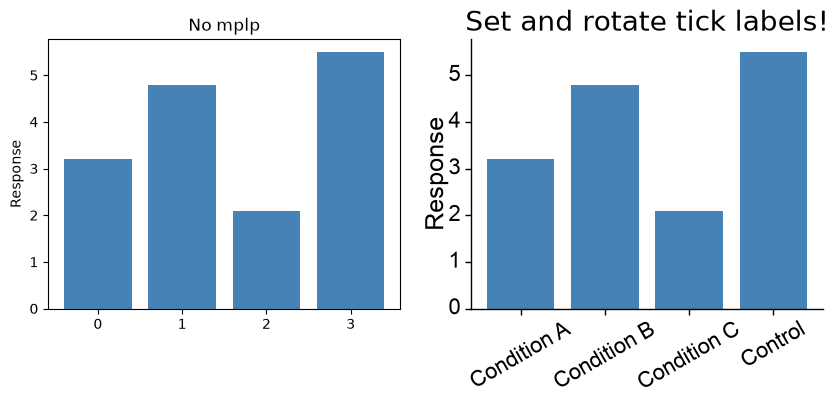

In [ ]:
categories = ['Condition A', 'Condition B', 'Condition C', 'Control']
values = [3.2, 4.8, 2.1, 5.5]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.bar(range(len(values)), values, color='steelblue')
    ax.set_ylabel('Response')
axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    xticks=range(len(values)),
    xtickslabels=categories,
    xtickrot=30,
    xtickha='center',
    ylabel='Response',
    title='Set and rotate tick labels!',
)

---
## 5. Subplots with `hspace` / `wspace`

Text(0.5, 1.0, 'Set grid h and v spacing!')

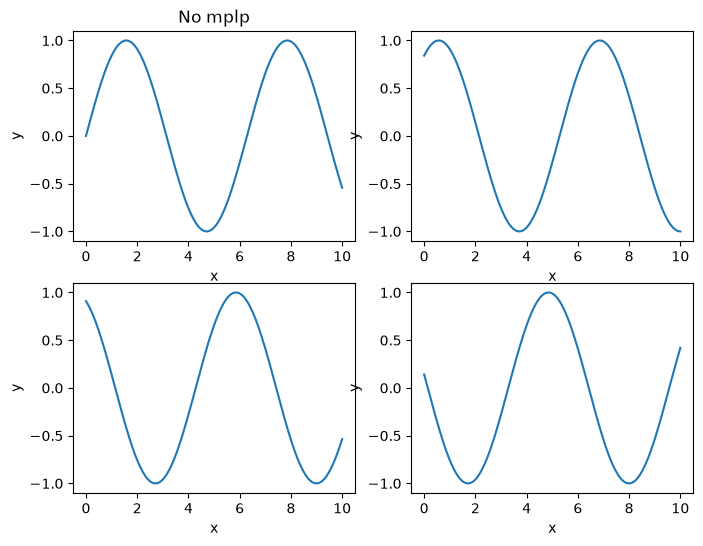

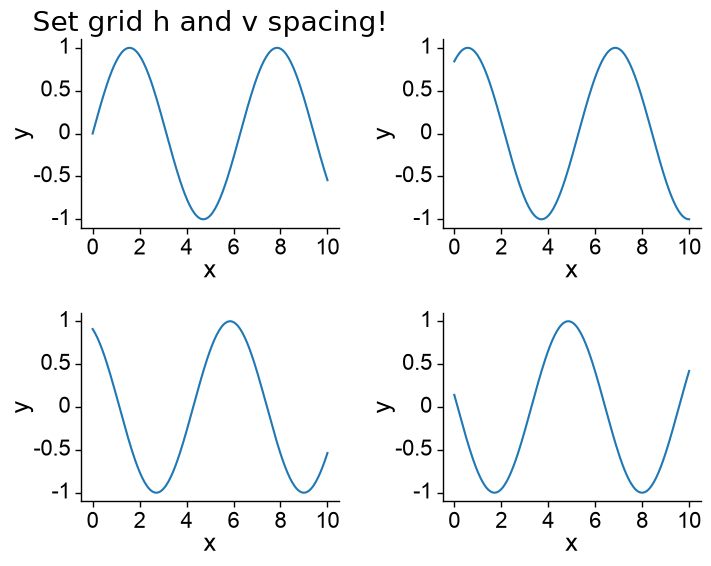

In [ ]:
fig1, all_axes1 = plt.subplots(2, 2, figsize=(8, 6))

# --- Before (left 2x2) ---
for i, ax in enumerate(all_axes1[:, :].flat):
    ax.plot(x, np.sin(x + i))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
all_axes1[0, 0].set_title('Default matplotlib')

fig2, all_axes2 = plt.subplots(2, 2, figsize=(8, 6))
# --- After (right 2x2) ---
for i, ax in enumerate(all_axes2[:, :].flat):
    ax.plot(x, np.sin(x + i))
    mplp.mplp(ax=ax, xlabel='x', ylabel='y',
              hspace=0.45, wspace=0.4)
all_axes2[0, 0].set_title('Set grid h and v spacing!', size=20)

---
## 6. Horizontal & vertical reference lines

(<Figure size 1000x350 with 2 Axes>,
 <Axes: title={'center': 'Set reference lines!'}, xlabel='x', ylabel='y'>)

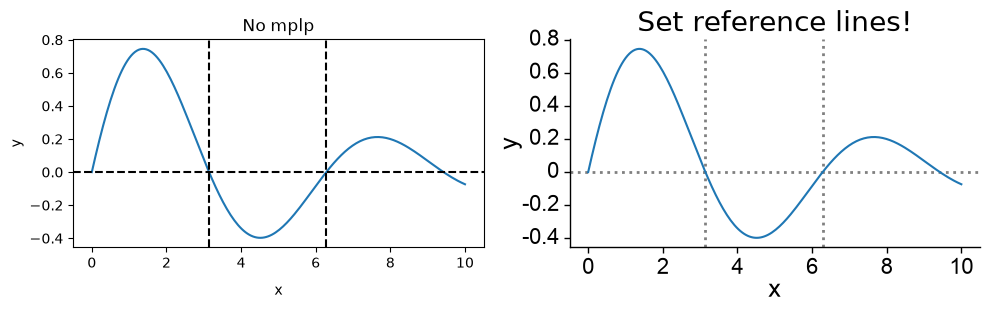

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(x, y)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

# Before: manual reference lines
axes[0].axhline(y=0, lw=1.5, ls='--', color='k')
axes[0].axvline(x=np.pi, lw=1.5, ls='--', color='k')
axes[0].axvline(x=2*np.pi, lw=1.5, ls='--', color='k')
axes[0].set_title('Default matplotlib')

# After: reference lines via mplp
mplp.mplp(
    ax=axes[1],
    hlines=[0],
    vlines=[np.pi, 2 * np.pi],
    lines_kwargs={'lw': 2, 'ls': ':', 'color': 'grey'},
    xlabel='x', ylabel='y',
    title='Set reference lines!',
    tight_layout=True,
)

---
## 7. Legend control

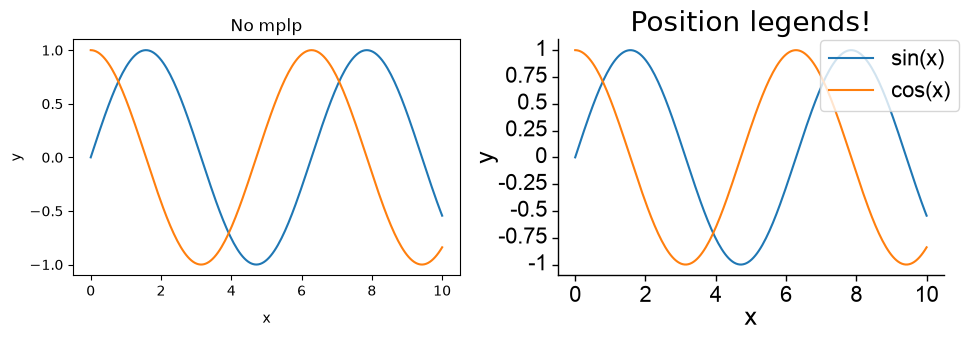

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(x, np.sin(x), label='sin(x)')
    ax.plot(x, np.cos(x), label='cos(x)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    show_legend=True,
    legend_loc=(0.65, 0.65),
    xlabel='x', ylabel='y',
    title='Position legends!',
)

fig.tight_layout()

---
## 8. Heatmap with colorbar

(<Figure size 1548.39x519.481 with 3 Axes>,
 <Axes: title={'center': 'Add custom colorbars!'}, xlabel='Feature', ylabel='Sample'>)

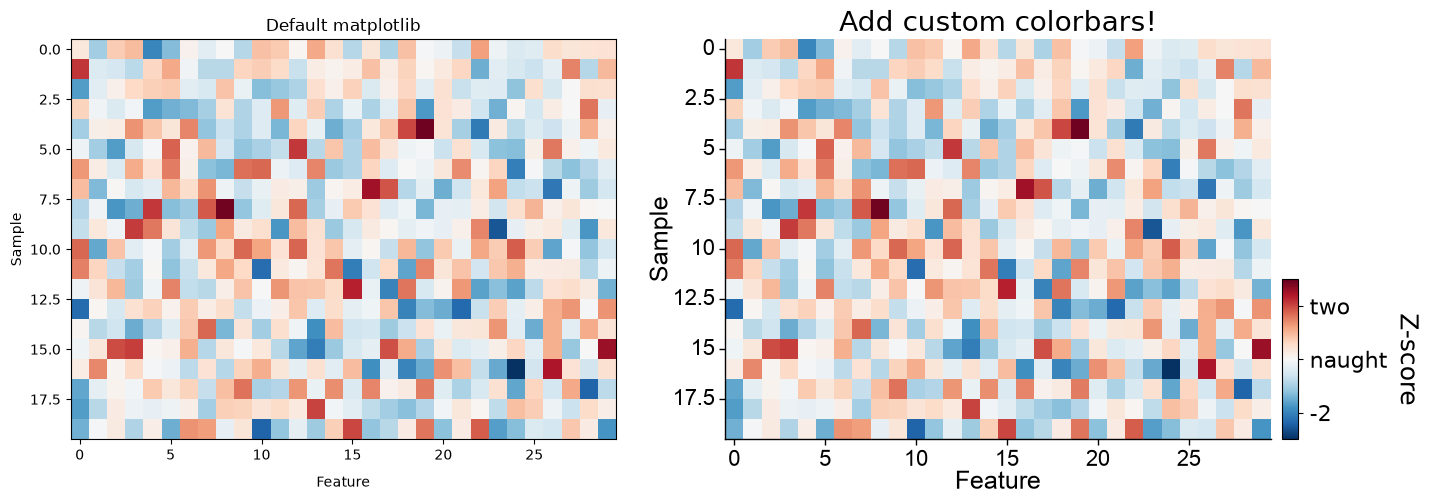

In [37]:
data = np.random.default_rng(42).normal(size=(20, 30))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Sample')

axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    colorbar=True,
    vmin=-3, vmax=3,
    cmap='RdBu_r',
    clabel='Z-score',
    cticks=[-2, 0, 2],
    ctickslabels=['-2', 'naught', 'two'],
    cbar_pad=0.02,
    xlabel='Feature', ylabel='Sample',
    title='Add custom colorbars!',
)

---
## 9. Color utilities

In [11]:
# Convert between color representations
print('to_rgb("steelblue"):', mplp.to_rgb('steelblue'))
print('to_hex((0.27, 0.51, 0.71)):', mplp.to_hex((0.27, 0.51, 0.71)))
print('to_hex((70, 130, 180)):', mplp.to_hex((70, 130, 180)))  # 0-255 range
print('to_hsv("steelblue"):', mplp.to_hsv('steelblue'))

to_rgb("steelblue"): (0.27450980392156865, 0.5098039215686274, 0.7058823529411765)
to_hex((0.27, 0.51, 0.71)): #4582b5
to_hex((70, 130, 180)): #4682b4
to_hsv("steelblue"): [0.57575758 0.61111111 0.70588235]


In [12]:
# Get N evenly-spaced colors from any colormap
colors = mplp.get_ncolors_cmap(8, 'viridis', plot=True)

In [13]:
# Get families of perceptually similar colors (great for grouped bar charts)
families = mplp.get_color_families(ncolors=3, nfamilies=4)
for fam in families:
    mplp.html_palette(fam)

---
## 10. Bounded (off-center diverging) colormap

(<Figure size 1419.35x454.545 with 4 Axes>,
 <Axes: title={'center': 'Make asymmetric colorbars with custom limits!'}>)

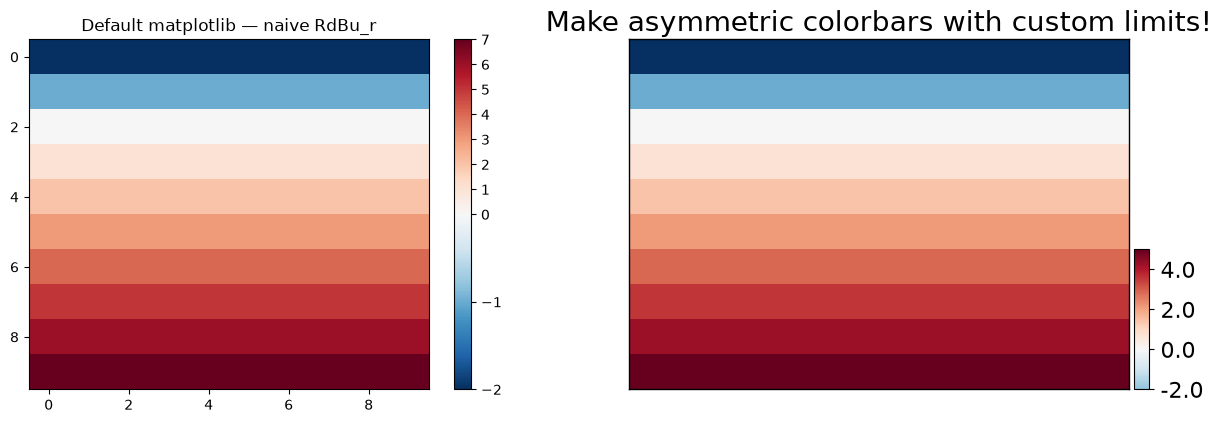

In [36]:
# Data where 0 isn't the midpoint of the range [-2, 5]
# make it a continuous gradient in 2D
from matplotlib.colors import TwoSlopeNorm
data_asym = np.tile(np.arange(-2, 8)[:, None], (1, 10))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].imshow(data_asym, aspect='auto', cmap='RdBu_r',
               norm=TwoSlopeNorm(vmin=-2, vcenter=0, vmax=7))
axes[0].set_title('Default matplotlib — naive RdBu_r')
# add colorbar
plt.colorbar(axes[0].images[0], ax=axes[0])


axes[1].imshow(data_asym, aspect='auto', cmap='RdBu_r',
               norm=TwoSlopeNorm(vmin=-2, vcenter=0, vmax=7))
mplp.mplp(ax=axes[1],
          title='Make asymmetric colorbars with custom limits!',
          hide_top_right=False,
          colorbar=True,
          cmap='RdBu_r',
          vmin=-2,
          center=0,
          vmax=5,
          xticks=[], yticks=[],
          )

---
## 11. Scientific notation with `sci_notation`

(<Figure size 1000x350 with 2 Axes>,
 <Axes: title={'center': 'Handles sci. notation'}, xlabel='x', ylabel='y'>)

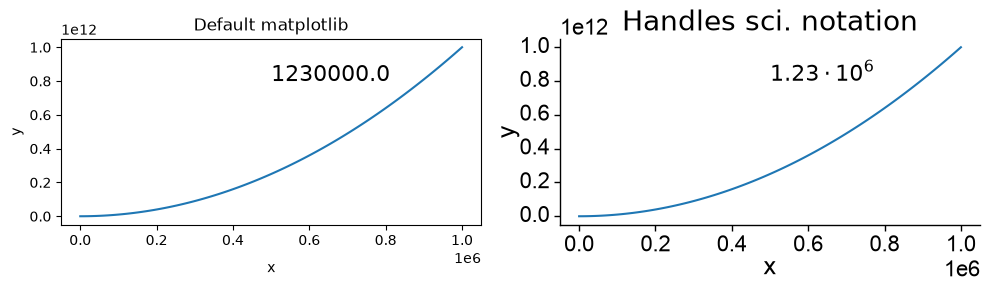

In [35]:
xbig = np.linspace(0, 1e6, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(xbig, xbig ** 2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes[0].set_title('Default matplotlib')
axes[0].text(5e5, 8e11, 1.23e6, fontsize=16)

axes[1].text(5e5, 8e11, mplp.sci_notation(1.23e6, 2), fontsize=16)
mplp.mplp(ax=axes[1], xlabel='x', ylabel='y', title='Handles sci. notation', tight_layout=True)

---
## 12. `prettify=False` — selective formatting

Set `prettify=False` to only apply the parameters you explicitly pass, leaving everything else untouched.

(<Figure size 1400x350 with 3 Axes>,
 <Axes: title={'center': 'prettify=False'}, xlabel='x', ylabel='y'>)

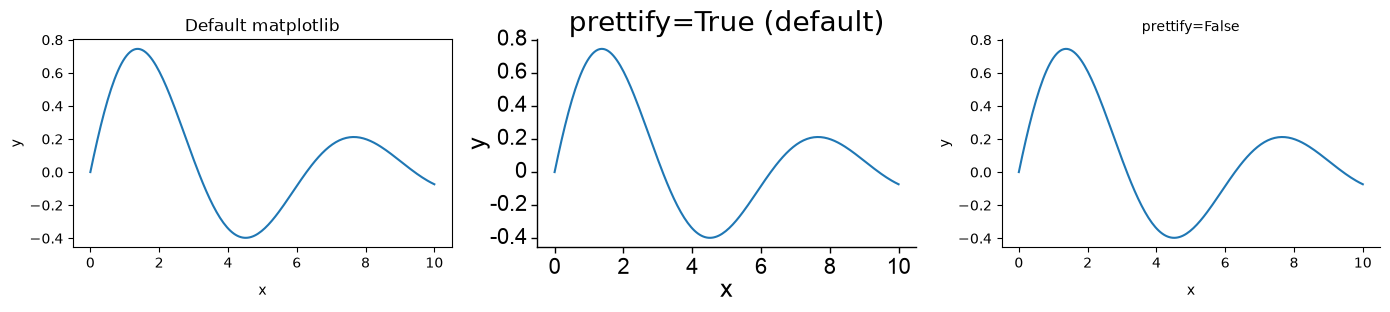

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax in axes:
    ax.plot(x, y)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes[0].set_title('Default matplotlib')

# prettify=True (default): full styling
mplp.mplp(ax=axes[1], title='prettify=True (default)')

# prettify=False: only change what you specify
mplp.mplp(ax=axes[2], prettify=False,
          title='prettify=False',
          hide_top_right=True,
          tight_layout=True)

---
## 13. Scalebars — neuroscience-style traces

Replace axes with scalebars, typical for electrophysiology / neural recordings
(similar to what [NeuroPyxels](https://github.com/m-beau/NeuroPyxels) would produce).

(<Figure size 1200x400 with 2 Axes>,
 <Axes: title={'center': 'Make nice scalebars!'}>)

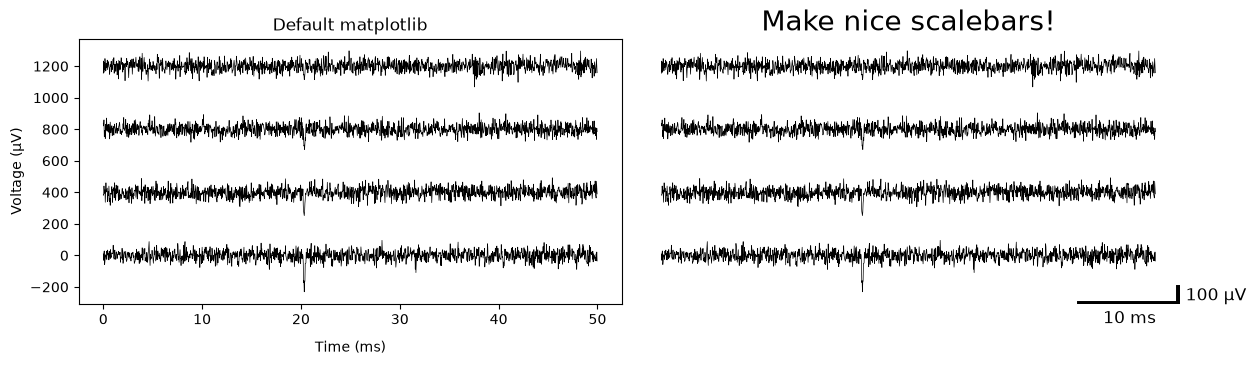

In [32]:
# Simulate a short extracellular recording snippet (4 channels)
rng = np.random.default_rng(42)
fs = 30_000  # 30 kHz
duration = 0.05  # 50 ms
t = np.arange(0, duration, 1 / fs) * 1000  # time in ms
n_channels = 4

# Bandpass-like noise + a fake spike
traces = rng.normal(0, 30, (n_channels, len(t)))
spike_t = int(0.02 * fs)  # spike at 20 ms
spike_wave = -200 * np.exp(-((np.arange(30) - 10) ** 2) / 8)
for ch in range(n_channels):
    traces[ch, spike_t:spike_t + 30] += spike_wave * (1 - 0.2 * ch)

offsets = np.arange(n_channels) * 400

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    for ch in range(n_channels):
        ax.plot(t, traces[ch] + offsets[ch], color='k', lw=0.5)

axes[0].set_title('Default matplotlib')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Voltage (\u03BCV)')

mplp.mplp(
    ax=axes[1],
    hide_axis=True,
    xscalebar=10,          # 10 ms
    yscalebar=100,         # 100 uV
    xscalebar_unit=' ms',
    yscalebar_unit=' \u03BCV',
    scalebarkwargs={'loc': 'right', 'fontsize': 12, 'lw': 5},
    title='Make nice scalebars!',
    tight_layout=True,
)

---
## 14. `hide_axis` & transparent background

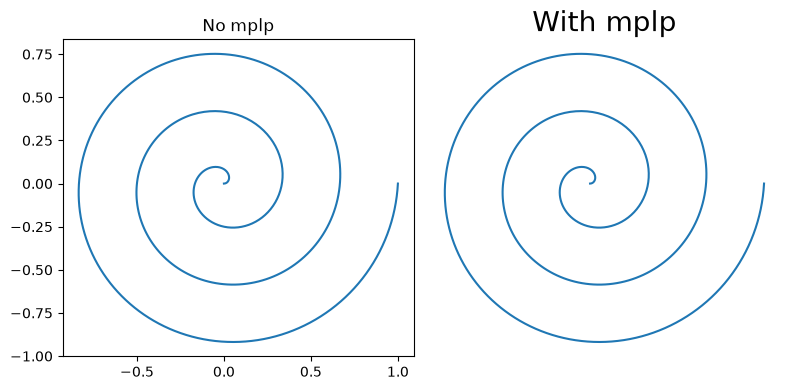

In [ ]:
theta = np.linspace(0, 6 * np.pi, 500)
r = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax in axes:
    ax.plot(r * np.cos(theta), r * np.sin(theta), lw=1.5)

axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    hide_axis=True,
    transparent_background=True,
    title='With mplp',
)

fig.tight_layout()
plt.show()

---
## 15. `set_ax_size` — set exact axis dimensions

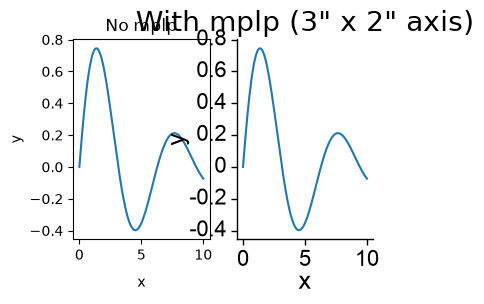

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    ax.plot(x, y)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes[0].set_title('Default matplotlib')

mplp.mplp(ax=axes[1], axsize=(3, 2), xlabel='x', ylabel='y',
          title='With mplp (3\" x 2\" axis)')

plt.show()

---
## 16. Saving figures

`mplp()` can save in one call. Text is kept editable (Type 42 fonts in PDF/PS).

In [20]:
# Uncomment to save:
# fig, ax = plt.subplots()
# ax.plot(x, y)
# mplp.mplp(ax=ax, saveFig=True, saveDir='./figures', figname='demo', _format='pdf')

---
## 17. Putting it all together

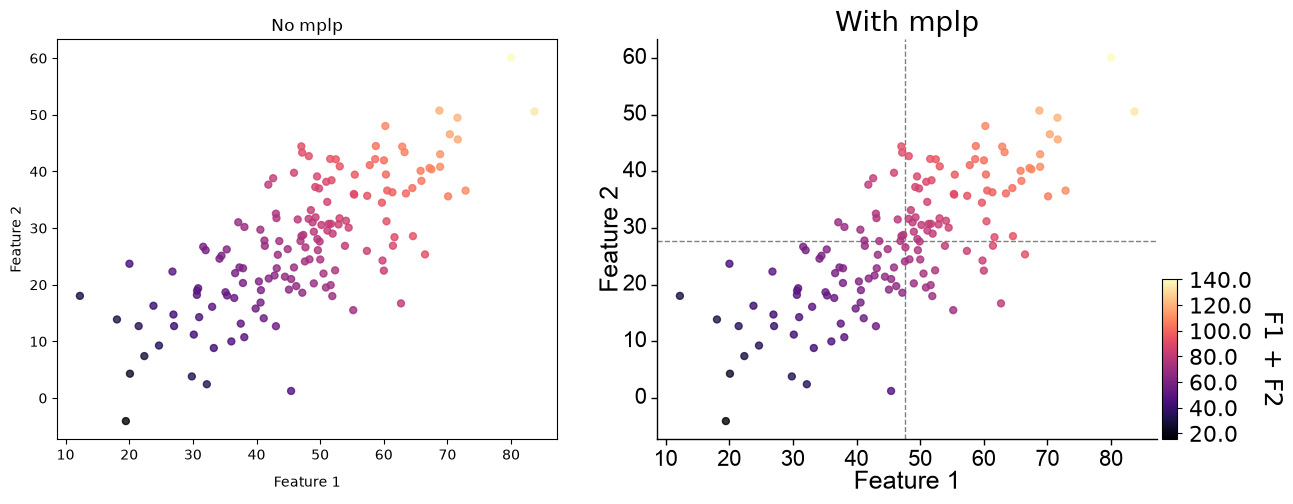

In [ ]:
rng = np.random.default_rng(7)
n = 150
x_data = rng.normal(50, 15, n)
y_data = 0.6 * x_data + rng.normal(0, 8, n)
colors_scatter = x_data + y_data

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax in axes:
    ax.scatter(x_data, y_data, c=colors_scatter, cmap='magma', s=25, alpha=0.8)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

axes[0].set_title('Default matplotlib')

mplp.mplp(
    ax=axes[1],
    xlabel='Feature 1',
    ylabel='Feature 2',
    title='With mplp',
    colorbar=True,
    vmin=colors_scatter.min(),
    vmax=colors_scatter.max(),
    cmap='magma',
    clabel='F1 + F2',
    hlines=[y_data.mean()],
    vlines=[x_data.mean()],
    lines_kwargs={'lw': 1, 'ls': '--', 'color': 'grey', 'zorder': -1},
)

# fig.tight_layout()
plt.show()